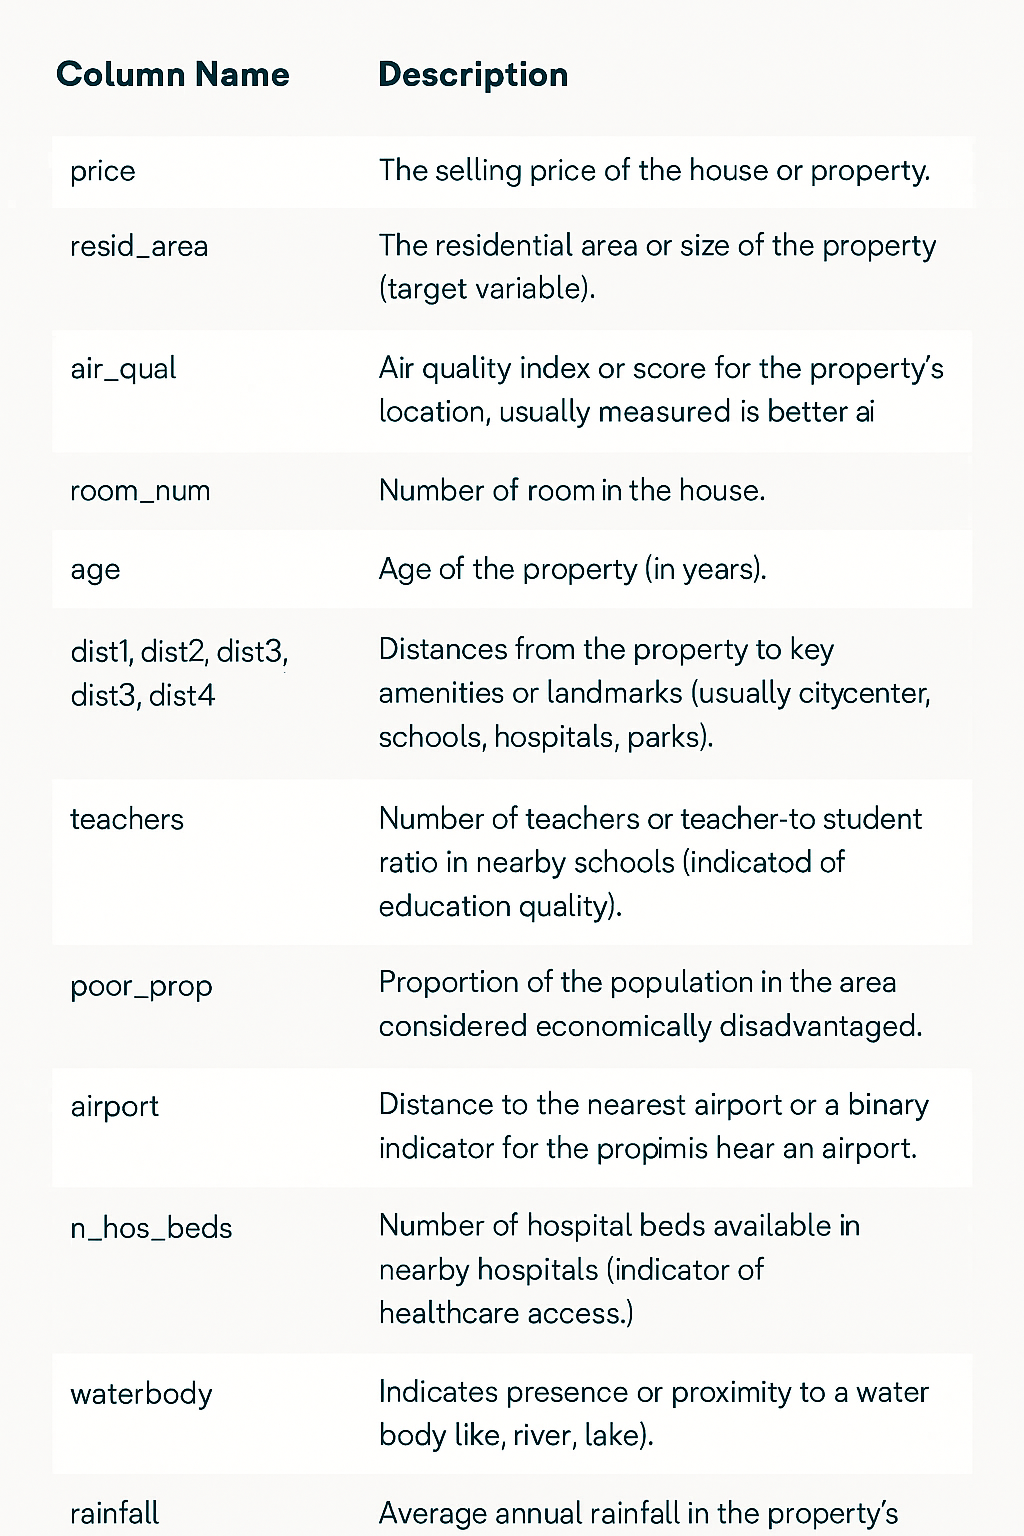

## Step : 1 Import Required Python Library / Load Dataset

### Import Required Library

In [1]:
# for inside data
import numpy as np

# for dataframe 
import pandas as pd

# for visulation
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [3]:
df = pd.read_csv('Data/House-Price.csv')
df.head()

,price,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,parks,Sold
0,24.0,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,YES,5.480,11.1920,River,23,YES,0.049347,0
1,21.6,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,NO,7.332,12.1728,Lake,42,YES,0.046146,1
2,34.7,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,NO,7.394,101.1200,NaN,38,YES,0.045764,0
3,33.4,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,YES,9.268,11.2672,Lake,45,YES,0.047151,0
4,36.2,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,NO,8.824,11.2896,Lake,55,YES,0.039474,0


## Step :- 2 Basic Information

#### i) Columns names

In [4]:
df.columns

Index(['price', 'resid_area', 'air_qual', 'room_num', 'age', 'dist1', 'dist2',
       'dist3', 'dist4', 'teachers', 'poor_prop', 'airport', 'n_hos_beds',
       'n_hot_rooms', 'waterbody', 'rainfall', 'bus_ter', 'parks', 'Sold'],
      dtype='object')

#### ii) Check duplicate rows

In [5]:
df.duplicated().sum()

0

#### iii) Check Numbers of Rows and Columns

In [6]:
print(f"Number of Columns :- {df.shape[1]}")
print(f"Number of Rows    :- {df.shape[0]}")

Number of Columns :- 19
Number of Rows    :- 506


#### iv) Check for Null values

In [7]:
df.isnull().sum()

price            0
resid_area       0
air_qual         0
room_num         0
age              0
dist1            0
dist2            0
dist3            0
dist4            0
teachers         0
poor_prop        0
airport          0
n_hos_beds       8
n_hot_rooms      0
waterbody      155
rainfall         0
bus_ter          0
parks            0
Sold             0
dtype: int64

#### v) Check Data-Types of Columns

In [8]:
df.dtypes

price          float64
resid_area     float64
air_qual       float64
room_num       float64
age            float64
dist1          float64
dist2          float64
dist3          float64
dist4          float64
teachers       float64
poor_prop      float64
airport         object
n_hos_beds     float64
n_hot_rooms    float64
waterbody       object
rainfall         int64
bus_ter         object
parks          float64
Sold             int64
dtype: object

#### vi) Overall Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        506 non-null    float64
 1   resid_area   506 non-null    float64
 2   air_qual     506 non-null    float64
 3   room_num     506 non-null    float64
 4   age          506 non-null    float64
 5   dist1        506 non-null    float64
 6   dist2        506 non-null    float64
 7   dist3        506 non-null    float64
 8   dist4        506 non-null    float64
 9   teachers     506 non-null    float64
 10  poor_prop    506 non-null    float64
 11  airport      506 non-null    object 
 12  n_hos_beds   498 non-null    float64
 13  n_hot_rooms  506 non-null    float64
 14  waterbody    351 non-null    object 
 15  rainfall     506 non-null    int64  
 16  bus_ter      506 non-null    object 
 17  parks        506 non-null    float64
 18  Sold         506 non-null    int64  
dtypes: float

#### Interpretation
- This dataset contains `506 observations(Rows)` and `19 Attributes(Columns)`
- We have `16 Numerical Columns` and `3 Categorical Columns`
- This Datasets `Not contain Duplicate Values`
- Missing values are present in the `waterbody (155 records)` and `n_hos_beds (8 records)` columns of the dataset.

## Step :- 3 Data Preprocessing

### Null Value Handling
- There are two types of null values in a dataset:

- Valid null value: Represents implicit missing records

- Invalid null value: Represents explicit missing records

### Guidelines for Handling Null Values
- If the percentage of missing values is less than 10%, remove the observations.

- If the percentage of missing values is between 20% and 70%, impute the missing records.

- If the percentage of missing values is more than 80%, remove the attribute (column) entirely.

In [10]:
(df.isnull().sum()/df.shape[0]) * 100

price           0.000000
resid_area      0.000000
air_qual        0.000000
room_num        0.000000
age             0.000000
dist1           0.000000
dist2           0.000000
dist3           0.000000
dist4           0.000000
teachers        0.000000
poor_prop       0.000000
airport         0.000000
n_hos_beds      1.581028
n_hot_rooms     0.000000
waterbody      30.632411
rainfall        0.000000
bus_ter         0.000000
parks           0.000000
Sold            0.000000
dtype: float64

#### Interpretation
- We have `30.632411  % missinging values` in waterbody
- We have `1.5810280  % missinging values` in  n_hos_beds

In [11]:
# checking datatypes of waterbody

df['waterbody'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 506 entries, 0 to 505
Series name: waterbody
Non-Null Count  Dtype 
--------------  ----- 
351 non-null    object
dtypes: object(1)
memory usage: 4.1+ KB


In [12]:
# finding Mode of waterbody

df['waterbody'].mode()

0    River
Name: waterbody, dtype: object

In [13]:
# filling null value 

df['waterbody'] = df['waterbody'].fillna(value=df['waterbody'].mode()[0])

In [14]:
# Validate the change
(df.isnull().sum()/df.shape[0]) * 100

price          0.000000
resid_area     0.000000
air_qual       0.000000
room_num       0.000000
age            0.000000
dist1          0.000000
dist2          0.000000
dist3          0.000000
dist4          0.000000
teachers       0.000000
poor_prop      0.000000
airport        0.000000
n_hos_beds     1.581028
n_hot_rooms    0.000000
waterbody      0.000000
rainfall       0.000000
bus_ter        0.000000
parks          0.000000
Sold           0.000000
dtype: float64

In [15]:
# Droping Null Values from 'n_hos_beds'
df.dropna(axis=0,inplace=True)

In [16]:
# Validate the change
(df.isnull().sum()/df.shape[0]) * 100

price          0.0
resid_area     0.0
air_qual       0.0
room_num       0.0
age            0.0
dist1          0.0
dist2          0.0
dist3          0.0
dist4          0.0
teachers       0.0
poor_prop      0.0
airport        0.0
n_hos_beds     0.0
n_hot_rooms    0.0
waterbody      0.0
rainfall       0.0
bus_ter        0.0
parks          0.0
Sold           0.0
dtype: float64

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a method used to understand patterns present in the data.

There are generally three types of EDA:

1. **Univariate Analysis :** When we analyze a single column at a time, it is called univariate analysis.

2. **Bivariate Analysis :** When we analyze two columns together, it is called bivariate analysis.

3. **Multivariate Analysis :** When we analyze more than two columns at the same time, it is called multivariate analysis.

### Univariate Analysis 

In [17]:
# Let see the data
df.head()

,price,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,parks,Sold
0,24.0,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,YES,5.480,11.1920,River,23,YES,0.049347,0
1,21.6,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,NO,7.332,12.1728,Lake,42,YES,0.046146,1
2,34.7,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,NO,7.394,101.1200,River,38,YES,0.045764,0
3,33.4,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,YES,9.268,11.2672,Lake,45,YES,0.047151,0
4,36.2,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,NO,8.824,11.2896,Lake,55,YES,0.039474,0


In [18]:
# Segregated the data accoding to dtypes

df_cat = df.select_dtypes('object')

#### Univariate Analysis on Categorical Columns

In [19]:
df_cat.columns

Index(['airport', 'waterbody', 'bus_ter'], dtype='object')

#### airport

In [20]:
# count the "airport column"

df_cat['airport'].value_counts()

airport
YES    273
NO     225
Name: count, dtype: int64

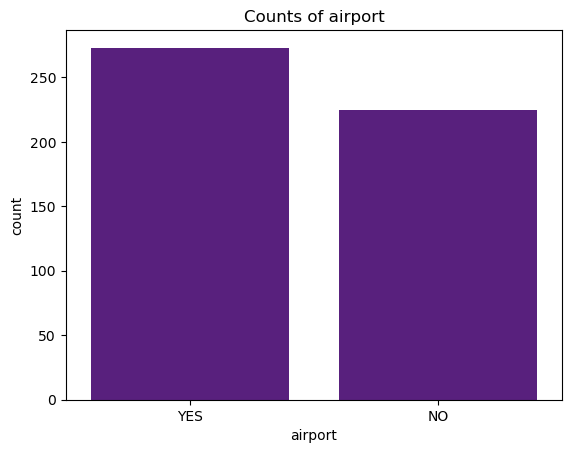

In [21]:
sns.countplot(x=df_cat['airport'],color='#5b118c')
plt.title('Counts of airport')
plt.show()

#### Interpretation
- 273 airports are contained in the airport column.
- 225 airports are not contained in it.

#### waterbody

In [22]:
df['waterbody'].value_counts()

waterbody
River             333
Lake               94
Lake and River     71
Name: count, dtype: int64

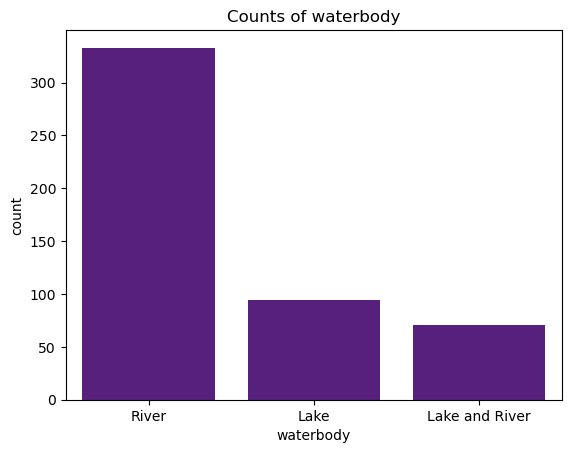

In [23]:
sns.countplot(x=df_cat['waterbody'],color='#5b118c')
plt.title('Counts of waterbody')
plt.show()

#### Interpretation
- We have 333 rivers in waterbody.

- We have 94 lakes in waterbody.

- We have 71 locations with both lake and river.

#### bus_ter

In [24]:
df['bus_ter'].value_counts()

bus_ter
YES    498
Name: count, dtype: int64

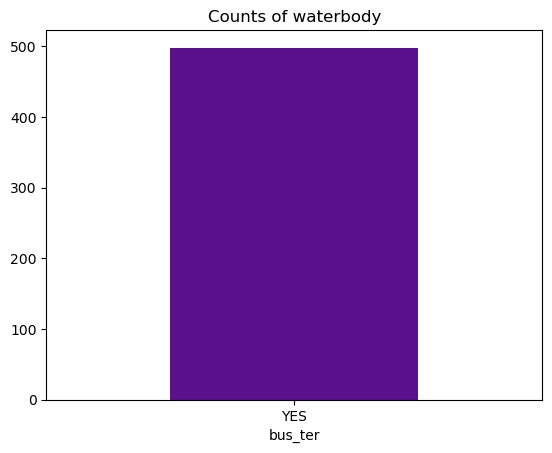

In [25]:
df_cat['bus_ter'].value_counts().plot(kind='bar',color='#5b118c')
plt.xticks(rotation=0)
plt.title('Counts of waterbody')
plt.show()

#### Interpretation
- We have 498 locations with a bus terminal.

## Univariate Analysis on Numerical Columns

In [26]:
df_num = df.select_dtypes('number')
df_num.head()

,price,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,n_hos_beds,n_hot_rooms,rainfall,parks,Sold
0,24.0,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,5.480,11.1920,23,0.049347,0
1,21.6,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,7.332,12.1728,42,0.046146,1
2,34.7,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,7.394,101.1200,38,0.045764,0
3,33.4,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,9.268,11.2672,45,0.047151,0
4,36.2,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,8.824,11.2896,55,0.039474,0


In [27]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
price,498.0,22.578715,9.191142,5.000000,17.025000,21.200000,25.000000,50.000000
resid_area,498.0,41.126526,6.881695,30.460000,35.145000,39.690000,48.100000,57.740000
air_qual,498.0,0.553869,0.115869,0.385000,0.449000,0.538000,0.624000,0.871000
room_num,498.0,6.287412,0.703900,3.561000,5.885500,6.210000,6.623500,8.780000
age,498.0,68.464056,28.253422,2.900000,44.550000,77.150000,94.100000,100.000000
dist1,498.0,3.985221,2.112560,1.130000,2.270000,3.405000,5.400000,12.320000
dist2,498.0,3.641988,2.113405,0.920000,1.940000,3.050000,5.000000,11.930000
dist3,498.0,3.973394,2.125105,1.150000,2.232500,3.395000,5.417500,12.320000
dist4,498.0,3.630462,2.104930,0.730000,1.940000,3.105000,5.005000,11.940000
teachers,498.0,21.541165,2.162552,18.000000,19.800000,20.950000,22.600000,27.400000


### Interpretation

* **Price**: The average house price is **22.58**, with prices ranging from **5.00** to **50.00**.
* **Residential Area (`resid_area`)**: The average residential area is **41.13**, ranging from **30.46** to **57.74**.
* **Air Quality Index (`air_qual`)**: The average air quality index is **0.55**, with values between **0.39** and **0.87**.
* **Number of Rooms (`room_num`)**: On average, houses have **6.29 rooms**, with a minimum of **3.56** and a maximum of **8.78**.
* **Age of Property (`age`)**: Properties are on average **68.46 years old**, ranging from **2.90** to **100.00** years.
* **Distance to Facility 1 (`dist1`)**: The average distance is **3.99**, with a range from **1.13** to **12.32**.
* **Distance to Facility 2 (`dist2`)**: The average distance is **3.64**, ranging from **0.92** to **11.93**.
* **Distance to Facility 3 (`dist3`)**: The average distance is **3.97**, with values between **1.15** and **12.32**.
* **Distance to Facility 4 (`dist4`)**: The average distance is **3.63**, ranging from **0.73** to **11.94**.
* **Number of Teachers (`teachers`)**: There are on average **21.54 teachers**, with a range from **18.00** to **27.40**.
* **Proportion of Poor Population (`poor_prop`)**: The average poor population proportion is **12.60**, with values from **1.73** to **37.97**.
* **Number of Hospital Beds (`n_hos_beds`)**: The average number of beds is **7.90**, ranging between **5.27** and **10.88**.
* **Number of Hot Rooms (`n_hot_rooms`)**: The average is **13.05**, with a minimum of **10.06** and a maximum of **101.12**.
* **Rainfall**: The average rainfall is **39.31**, ranging from **28.00** to **60.00**.
* **Number of Parks (`parks`)**: The average value is **0.05**, ranging from **0.03** to **0.09**.
* **Sold**: On average, **45.39%** of houses are sold, with values being either **0** (not sold) or **1** (sold).

## Bivariate Analysis
- When we analyze two columns together, it is called bivariate analysis.

In [28]:
# add rules here

In [29]:
df_num.corr()

,price,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,n_hos_beds,n_hot_rooms,rainfall,parks,Sold
price,1.000000,-0.482223,-0.430731,0.699058,-0.377020,0.250290,0.247989,0.245614,0.247557,0.503035,-0.739174,0.109646,0.023550,-0.045949,-0.394332,-0.152860
resid_area,-0.482223,1.000000,0.765253,-0.392985,0.646088,-0.708870,-0.709945,-0.709434,-0.707921,-0.377254,0.604767,0.005827,-0.002154,0.053703,0.710899,0.025342
air_qual,-0.430731,0.765253,1.000000,-0.306482,0.731412,-0.768092,-0.769134,-0.768611,-0.764470,-0.187878,0.592937,-0.049954,-0.005646,0.096328,0.914613,-0.005912
room_num,0.699058,-0.392985,-0.306482,1.000000,-0.242009,0.210926,0.206102,0.203989,0.207852,0.353065,-0.616850,0.032207,0.033327,-0.062524,-0.287410,0.023029
age,-0.377020,0.646088,0.731412,-0.242009,1.000000,-0.745827,-0.745320,-0.746066,-0.745545,-0.263129,0.602473,-0.021102,0.008179,0.075485,0.672773,-0.018631
dist1,0.250290,-0.708870,-0.768092,0.210926,-0.745827,1.000000,0.997897,0.997758,0.994090,0.234428,-0.498404,-0.030550,-0.013775,-0.037213,-0.703854,-0.035719
dist2,0.247989,-0.709945,-0.769134,0.206102,-0.745320,0.997897,1.000000,0.998107,0.994007,0.234892,-0.495017,-0.031248,-0.009507,-0.038528,-0.705896,-0.040708
dist3,0.245614,-0.709434,-0.768611,0.203989,-0.746066,0.997758,0.998107,1.000000,0.994101,0.234579,-0.494075,-0.028471,-0.009238,-0.041988,-0.707114,-0.036870
dist4,0.247557,-0.707921,-0.764470,0.207852,-0.745545,0.994090,0.994007,0.994101,1.000000,0.229601,-0.496093,-0.021648,-0.004937,-0.032807,-0.701352,-0.044891
teachers,0.503035,-0.377254,-0.187878,0.353065,-0.263129,0.234428,0.234892,0.234579,0.229601,1.000000,-0.372849,-0.008130,-0.021648,-0.038705,-0.188348,0.037893


1. (resid_area,parks)
2. (air_qual,parks)
3. (dist1,parks)
4. (dist2,parks)
5. (dist3,parks)
6. (dist4,parks)
7. (price,poor_prop)
8. (air_qual,age)
9. (resid_area,air_qual)

#### resid_area vs parks

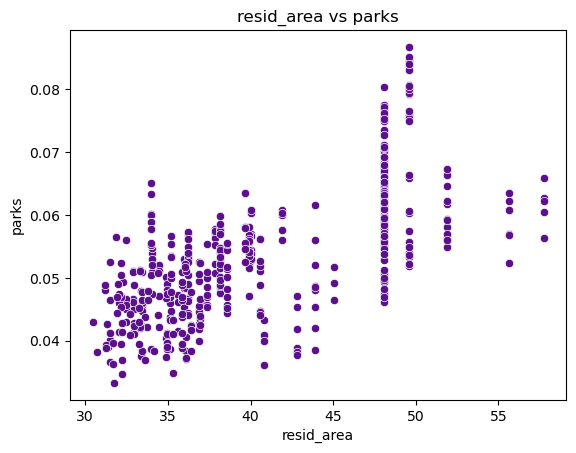

In [30]:
sns.scatterplot(x='resid_area',y='parks',data=df,color='#5b118c')
plt.title('resid_area vs parks')
plt.show()

#### Interpretation
- There is a positive relationship between resid_area and parks.
- This means that as the residential area increases, the number of parks also tends to increase.

### air_qual vs parks

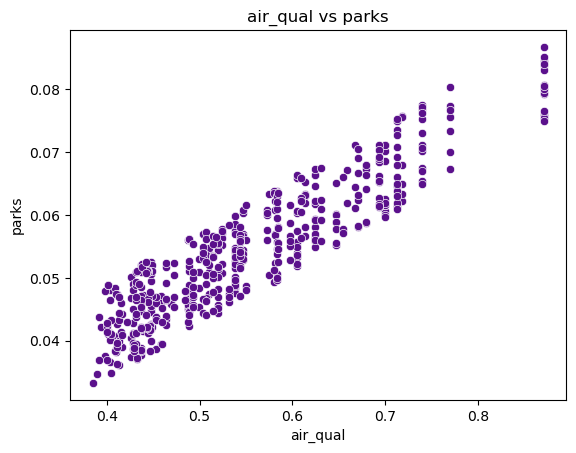

In [31]:
sns.scatterplot(x='air_qual',y='parks',data=df,color='#5b118c')
plt.title('air_qual vs parks')
plt.show()

#### Interpretation
- There is a positive relationship between air_qual and parks.
- This means that as the number of parks increases, the air quality also improves.

### dist1 vs parks

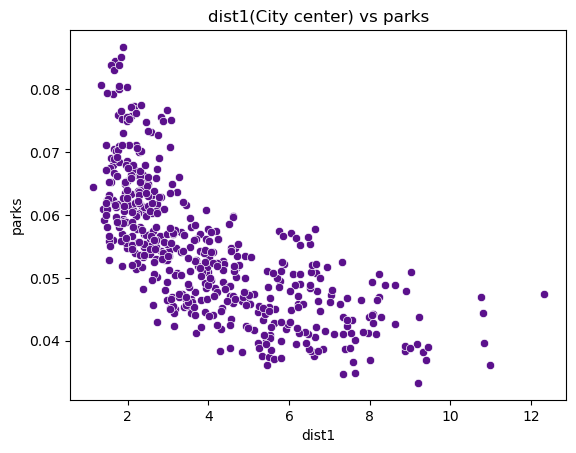

In [32]:
sns.scatterplot(x='dist1',y='parks',data=df,color='#5b118c')
plt.title('dist1(City center) vs parks')
plt.show()

#### Interpretation
- There is a negative relationship between dist1 and parks.
- This means that as the distance from the city center increases, the number of parks tends to decrease.

### dist2 vs parks

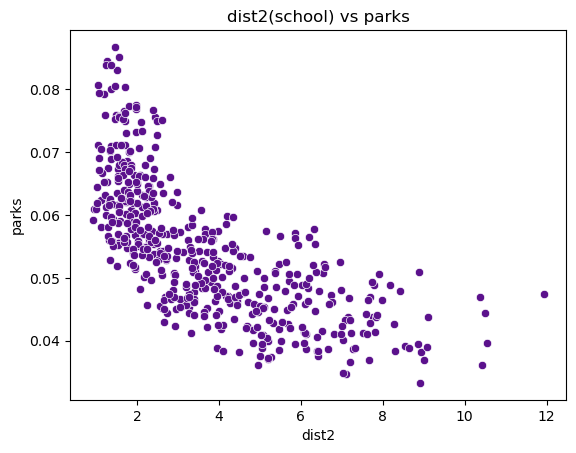

In [33]:
sns.scatterplot(x='dist2',y='parks',data=df,color='#5b118c')
plt.title('dist2(school) vs parks')
plt.show()

#### Interpretation
- There is a negative relationship between dist2 and parks.
- This means that as the distance from the School increases, the number of parks tends to decrease.

### dist3 vs parks

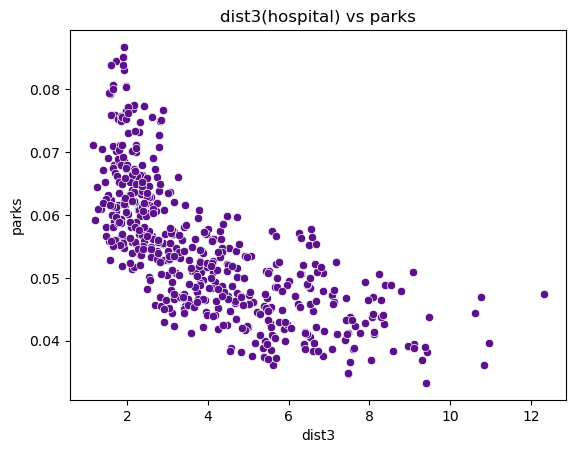

In [34]:
sns.scatterplot(x='dist3',y='parks',data=df,color='#5b118c')
plt.title('dist3(hospital) vs parks')
plt.show()

#### Interpretation
- There is a negative relationship between dist2 and parks.
- This means that as the distance from the Hospital increases, the number of parks tends to decrease.

### price vs poor_prop

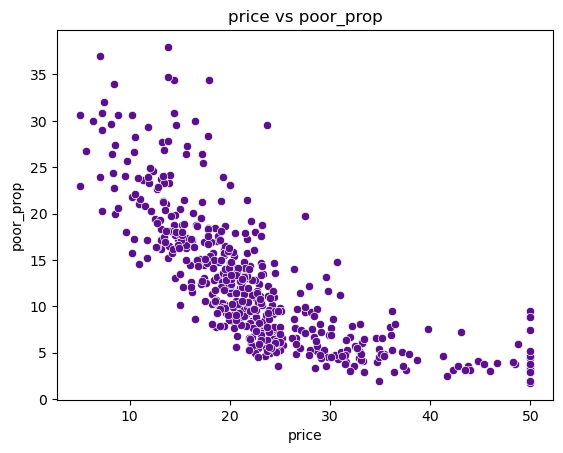

In [35]:
sns.scatterplot(x='price',y='poor_prop',data=df,color='#5b118c')
plt.title('price vs poor_prop')
plt.show()

#### Interpretation
- There is a negative relationship between house prices and the proportion of the poor population.
- This means that as house prices increase, areas tend to have a lower percentage of poor residents.

### air_qual vs age

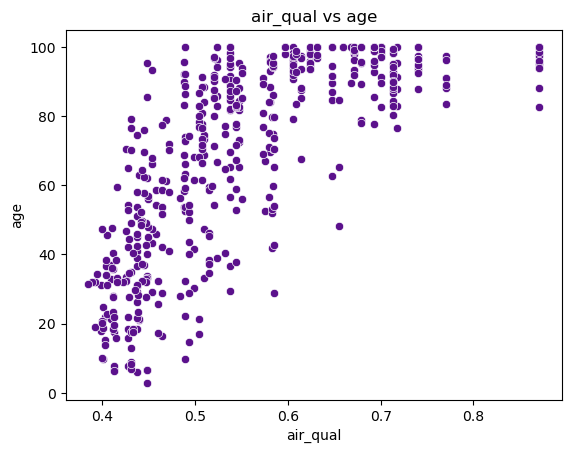

In [36]:
sns.scatterplot(x='air_qual',y='age',data=df,color='#5b118c')
plt.title('air_qual vs age')
plt.show()

#### Interpretation
- There is a positive relationship between air quality (air_qual) and house age, 
- Indicating that older houses are generally found in areas with better air quality.

### resid_area vs air_qual

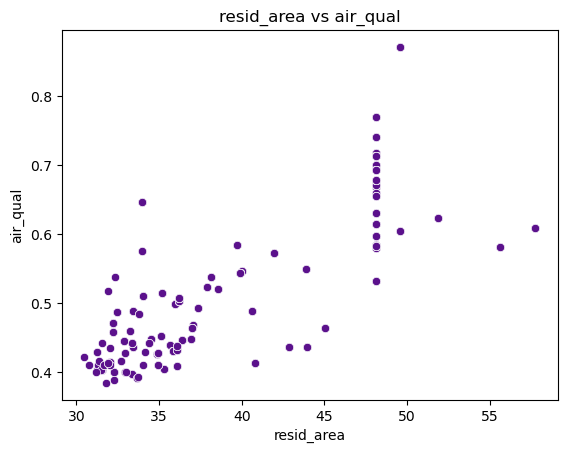

In [37]:
sns.scatterplot(x='resid_area',y='air_qual',data=df,color='#5b118c')
plt.title('resid_area vs air_qual')
plt.show()

#### Interpretation
- There is a positive relationship between  resident Area (resid_area) and air quality (air_qual).
- Its mean that as resident Area increase the air quality tend to increase.

### Multivariate Analysis
When we analyze more than two columns at the same time, it is called multivariate analysis.

In [38]:
# airport and waterbody
# air_qual vs parks
# resid_area,air_qual

#### Resident Area

In [39]:
pd.crosstab(index=df['airport'],columns=df['waterbody'],values=df['resid_area'],aggfunc='min')

waterbody,Lake,Lake and River,River
airport,,,
NO,31.47,32.03,31.25
YES,30.74,31.38,30.46


#### Interpretation
- For areas with a lake, the minimum residential area is slightly smaller near airports (30.74) compared to areas without airports (31.47).
- For areas with both lake and river, the minimum residential area is lower near airports (31.38) than in areas without airports (32.03).
- For areas with a river, the minimum residential area is slightly smaller near airports (30.46) compared to areas without airports (31.25).

In [40]:
pd.crosstab(index=df['airport'],columns=df['waterbody'],values=df['resid_area'],aggfunc='max')

waterbody,Lake,Lake and River,River
airport,,,
NO,55.65,51.89,57.74
YES,55.65,57.74,57.74


#### Interpretation
 - For areas with a lake, the maximum residential area is equal to near airports (55.65) and without airports (55.65).
 - For areas with both lake and river, the maximum residential area is lower without airports (51.89) than in areas near airports (57.74).
 - For areas with a river, the maximum residential area is equal to near airports (57.74) compared to areas without airports (57.74).

In [41]:
pd.crosstab(index=df['airport'],columns=df['waterbody'],values=df['resid_area'],aggfunc='mean')

waterbody,Lake,Lake and River,River
airport,,,
NO,41.556923,43.366053,41.761284
YES,40.192545,40.454848,40.465459


#### Interpretation
 - For areas with a lake, the average residential area is slightly smaller near airports (40.19) compared to areas without airports (41.55).
 - For areas with both lake and river, the average residential area is lower near airports (40.45) than in areas without airports (43.36).
 - For areas with a river, the average residential area is slightly smaller near airports (40.46) compared to areas without airports (41.76).

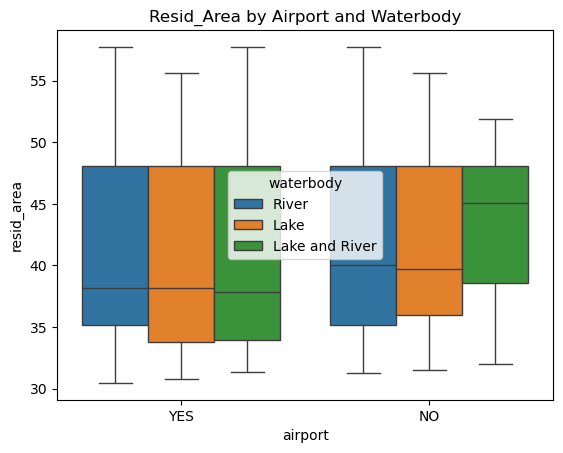

In [42]:
sns.boxplot(x='airport', y='resid_area', hue='waterbody', data=df)
plt.title('Resid_Area by Airport and Waterbody')
plt.show()

### Air quality

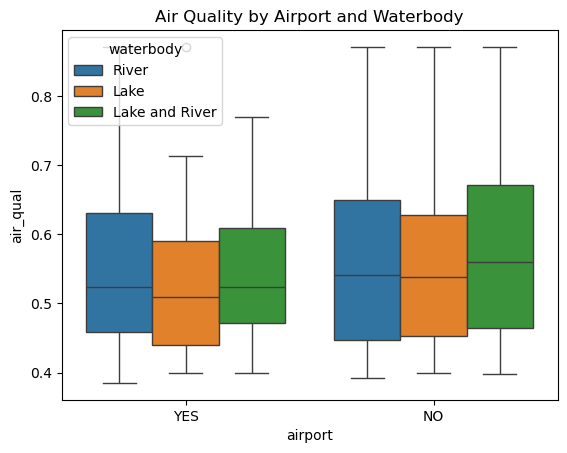

In [47]:
sns.boxplot(x=df['airport'],y=df['air_qual'],hue=df['waterbody'])
plt.title('Air Quality by Airport and Waterbody')
plt.show()

In [43]:
pd.crosstab(index=df['airport'] , columns=df['waterbody'] , values=df['air_qual'],aggfunc='min')

waterbody,Lake,Lake and River,River
airport,,,
NO,0.4,0.398,0.392
YES,0.4,0.400,0.385


#### Interpretation
 - For quality of air near a lake, the minimum air quality is equal to near airports (0.4) and areas without airports (0.4).
 - For quality of air near both lake and river, the minimum air quality is slightly lower without airports (0.39) than in areas near airports (0.4).
 - For quality of air near a river, the minimum air quality is slightly lower near airports (0.385) compared to areas without airports (0.392).

In [44]:
pd.crosstab(index=df['airport'] , columns=df['waterbody'] , values=df['air_qual'],aggfunc='max')

waterbody,Lake,Lake and River,River
airport,,,
NO,0.871,0.871,0.871
YES,0.871,0.770,0.871


#### Interpretation
 - For quality of air near a lake, the maximum air quality is equal to near airports (0.871) and areas without airports (0.871).
 - For quality of air near both lake and river, the maximum air quality is slightly lower near airports (0.77) than in areas without airports (0.871).
 - For quality of air near a river, the maximum air quality is equal to near airports (0.871) and areas without airports (0.871).

In [45]:
pd.crosstab(index=df['airport'] , columns=df['waterbody'] , values=df['air_qual'],aggfunc='mean')

waterbody,Lake,Lake and River,River
airport,,,
NO,0.559790,0.574842,0.561068
YES,0.527235,0.540033,0.552940


#### Interpretation
 - For quality of air near a lake, the average air quality is slightly lower near airports (0.52) than in areas without airports (0.55).
 - For quality of air near both lake and river, the average air quality is slightly lower near airports (0.54) than in areas without airports (0.57).
 - For quality of air near a river, the average air quality is slightly lower near airports (0.55) than in areas without airports (0.56).

# **Conclusion of House Price Exploratory Data Analysis**

In this analysis, we studied different factors that affect house prices. We looked at each column in the data, checked for missing values, and explored how different features are related to the price of a house.

### **Main Findings:**

##### 1. **Basic Property Information:**

* The **average house price** is around 22.58, with prices between 5 and 50.
* The **size of houses**, **number of rooms**, and **age** vary a lot.
* **Air quality** is mostly average, but some areas are much better or worse.
* Distance from schools, hospitals, and city centers varies a lot and may affect prices.

##### 2. **Environment and Society:**

* Areas with **more parks** usually have **cleaner air**.
* Places with **more poor population** tend to have **lower house prices**.
* **Older houses** are often in areas with **better air**, maybe because they were built before pollution increased.

##### 3. **Location & Facilities:**

* The **further a house is from the city**, the **fewer parks** are nearby.
* This shows that **urban areas** are better planned with more green spaces.

##### 4. **Geographic Factors:**

* Houses near **airports** tend to be smaller and have poorer air quality.
* But the **highest values** for air quality and size are not much different, so airport effect may be small or specific to some places.
